# 📘 Notebook explicatif — Démarche ML appliquée au dataset *Canada per capita income*

Ce notebook suit la démarche convenue (EDA → Préprocessing → Modélisation) et illustre chaque étape de manière pédagogique, en s'appuyant sur le fichier `canada_per_capita_income.csv`.

## 🎯 Objectif

Prédire le **revenu par habitant (US$)** à partir de l'année (`year`). Le dataset est petit (47 lignes), ce qui permet une démarche simple et transparente pour illustrer les concepts.

## Import Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from sklearn.model_selection import train_test_split, learning_curve, validation_curve
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import joblib as jb


# --- IGNORE ---

## Chargement des data 💾

In [3]:
url = "./Datasets/canada_per_capita_income.csv"

income_df = pd.read_csv(url)
income_df.head()

,year,per capita income (US$)
0,1970,3399.299037
1,1971,3768.297935
2,1972,4251.175484
3,1973,4804.463248
4,1974,5576.514583


## 1) EDA — Exploratory Data Analysis

### 1.1 Analyse de forme
- Identification de la **target** : `per capita income (US$)`
- Nombre de lignes / colonnes, types, valeurs manquantes

In [5]:
# Dimensions of the dataset === rows, columns number
income_df.shape

(47, 2)

In [8]:
# Typage of each column
display(income_df.dtypes)
income_df.info()

year                         int64
per capita income (US$)    float64
dtype: object

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 47 entries, 0 to 46
Data columns (total 2 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   year                     47 non-null     int64  
 1   per capita income (US$)  47 non-null     float64
dtypes: float64(1), int64(1)
memory usage: 884.0 bytes


In [11]:
# missing values
income_df.isnull().sum()  # No missing values

year                       0
per capita income (US$)    0
dtype: int64

<Axes: >

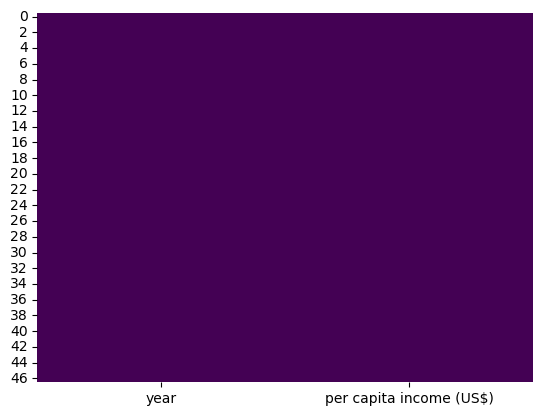

In [15]:
sns.heatmap(income_df.isnull(), cbar=False, cmap='viridis')

### 1.2 Analyse de fond
- Visualisation de la **target** (histogramme + boxplot)
- Compréhension de la relation `year` → `per capita income (US$)`
- Identification visuelle d'éventuels **outliers**

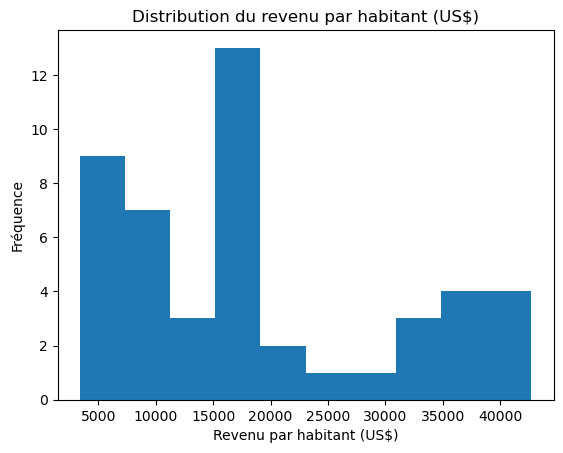

In [16]:
# Histogramme de la target
plt.figure()
plt.hist(income_df["per capita income (US$)"], bins=10)
plt.title("Distribution du revenu par habitant (US$)")
plt.xlabel("Revenu par habitant (US$)")
plt.ylabel("Fréquence")
plt.show()

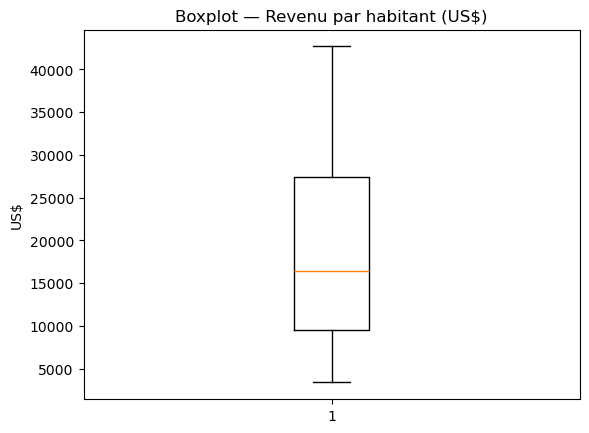

In [18]:
# Boxplot de la target
plt.figure()
plt.boxplot(income_df["per capita income (US$)"].dropna(), vert=True)
plt.title("Boxplot — Revenu par habitant (US$)")
plt.ylabel("US$")
plt.show()

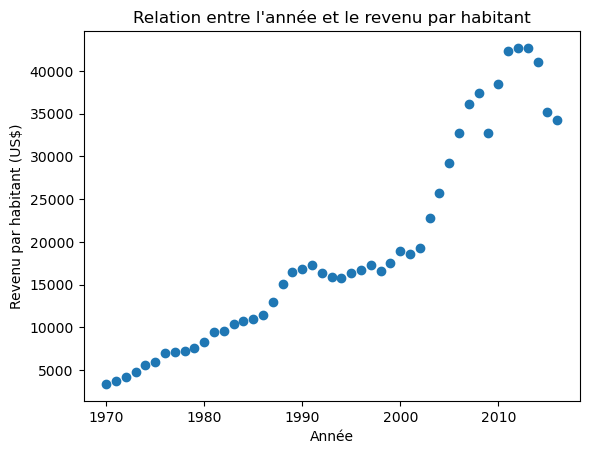

In [ ]:
# Relation year -> income
plt.figure()
plt.scatter(income_df["year"], income_df["per capita income (US$)"])
plt.title("Relation entre l'année et le revenu par habitant")
plt.xlabel("Année")
plt.ylabel("Revenu par habitant (US$)")
plt.show()

## 2) Préprocessing

Étapes simples adaptées au dataset :
- **Train/Test split** (80/20)
- (Pas de valeurs manquantes ni de variables catégorielles ici)
- **Feature scaling** non indispensable pour une régression linéaire simple avec 1 feature, on laisse tel quel.

In [ ]:
# Train Test Split
X = income_df[["year"]]
y = income_df["per capita income (US$)"]


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

display(X_train.shape, X_test.shape)
display(y_train.shape, y_test.shape)

(37, 1)

(10, 1)

(37,)

(10,)

## 3) Modélisation

- **Modèle** : Régression Linéaire
- **Fonctions d'évaluation** : MAE, RMSE, R²
- **Courbe d'apprentissage** pour estimer le bénéfice potentiel de plus de données

 

In [26]:
# Entraînement du modèle
reg = LinearRegression()
reg.fit(X_train, y_train)

LinearRegression()

In [48]:
# Evaluation du modèle
# Prédictions
y_pred_train = reg.predict(X_train)
y_pred_test = reg.predict(X_test)


# Metrics
def regression_metrics(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)
    return mae, mse, rmse, r2

In [ ]:

mae, mse, rmse, r2 = regression_metrics(y_train, y_pred_train)

In [30]:
mae

3002.3462702754055

MAE:  3,002.35
RMSE: 3,949.90
R²:   0.8934


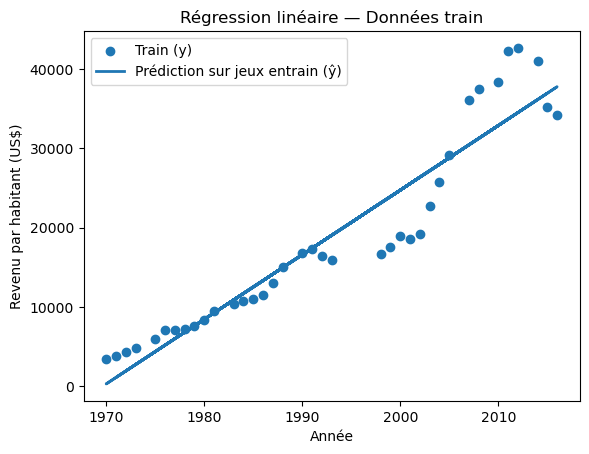

In [ ]:
print(f"MAE:  {mae:,.2f}")
print(f"RMSE: {rmse:,.2f}")
print(f"R²:   {r2_score:,.4f}")

# Visualisation : points test + droite de régression
plt.figure()
plt.scatter(X_train["year"], y_train, label="Train (y)")
plt.plot(X_train["year"], y_pred_train, linewidth=2,
         label="Prédiction sur jeux entrain (ŷ)")
plt.title("Régression linéaire — Données train")
plt.xlabel("Année")
plt.ylabel("Revenu par habitant (US$)")
plt.legend()
plt.show()

In [ ]:
mae, mse, rmse, r2 = regression_metrics(y_test, y_pred_test)

MAE:  3,240.91
RMSE: 3,892.02
R²:   0.8752


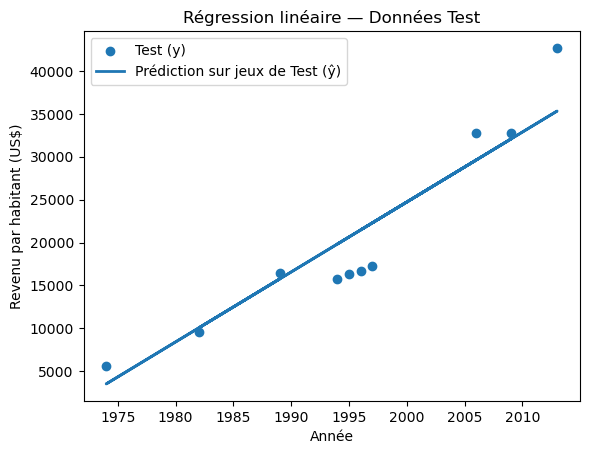

In [53]:
print(f"MAE:  {mae:,.2f}")
print(f"RMSE: {rmse:,.2f}")
print(f"R²:   {r2:,.4f}")

# Visualisation : points test + droite de régression
plt.figure()
plt.scatter(X_test["year"], y_test, label="Test (y)")
plt.plot(X_test["year"], y_pred_test, linewidth=2,
         label="Prédiction sur jeux de Test (ŷ)")
plt.title("Régression linéaire — Données Test")
plt.xlabel("Année")
plt.ylabel("Revenu par habitant (US$)")
plt.legend()
plt.show()

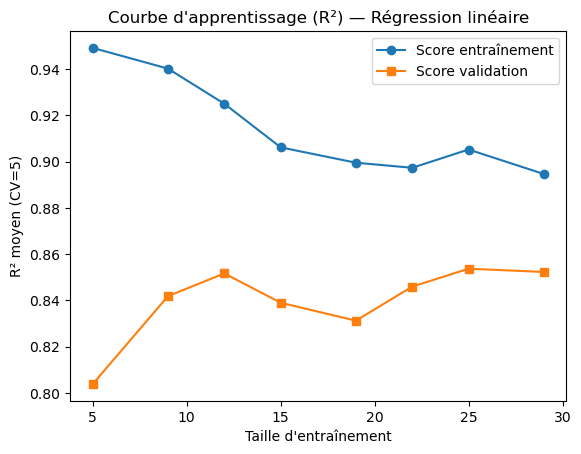

In [55]:
# Courbe d'apprentissage
train_sizes, train_scores, valid_scores = learning_curve(
    LinearRegression(), X_train, y_train, train_sizes=np.linspace(0.2, 1.0, 8), cv=5, scoring="r2"
)

train_mean = train_scores.mean(axis=1)
valid_mean = valid_scores.mean(axis=1)

plt.figure()
plt.plot(train_sizes, train_mean, marker="o", label="Score entraînement")
plt.plot(train_sizes, valid_mean, marker="s", label="Score validation")
plt.title("Courbe d'apprentissage (R²) — Régression linéaire")
plt.xlabel("Taille d'entraînement")
plt.ylabel("R² moyen (CV=5)")
plt.legend()
plt.show()

DecisionTreeRegressor

In [56]:
tree = DecisionTreeRegressor(max_depth=3, random_state=42)
tree.fit(X_train, y_train)
y_pred_tree_test = tree.predict(X_test)
y_pred_tree_train = tree.predict(X_train)

In [ ]:
mae, mse, rmse, r2 = regression_metrics(y_train, y_pred_tree_train)

MAE:  1,292.27
RMSE: 1,578.68
R²:   0.9830


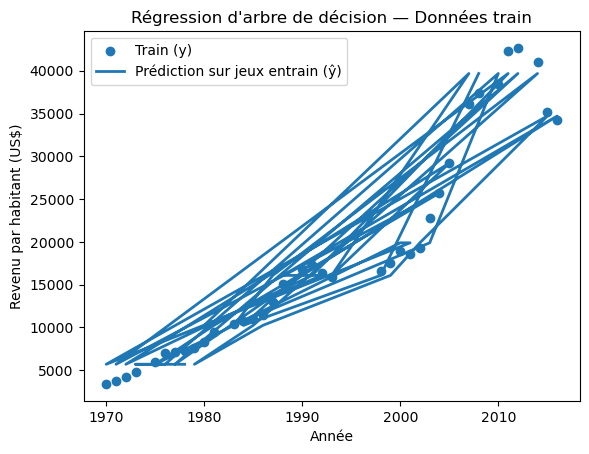

In [59]:
print(f"MAE:  {mae:,.2f}")
print(f"RMSE: {rmse:,.2f}")
print(f"R²:   {r2:,.4f}")

# Visualisation : points test + droite de régression
plt.figure()
plt.scatter(X_train["year"], y_train, label="Train (y)")
plt.plot(X_train["year"], y_pred_tree_train, linewidth=2,
         label="Prédiction sur jeux entrain (ŷ)")
plt.title("Régression d'arbre de décision — Données train")
plt.xlabel("Année")
plt.ylabel("Revenu par habitant (US$)")
plt.legend()
plt.show()

In [60]:
years = np.arange(1969, 2017).reshape(-1, 1)

In [62]:
y_pred_tree_train = tree.predict(years)

c:\Users\didie\anaconda3\envs\pythonTest\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeRegressor was fitted with feature names
  warnings.warn(


MAE:  1,292.27
RMSE: 1,578.68
R²:   0.9830


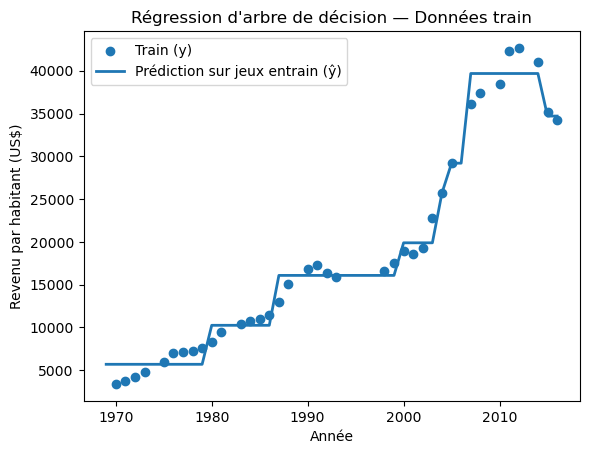

In [64]:
print(f"MAE:  {mae:,.2f}")
print(f"RMSE: {rmse:,.2f}")
print(f"R²:   {r2:,.4f}")

# Visualisation : points test + droite de régression
plt.figure()
plt.scatter(X_train, y_train, label="Train (y)")
plt.plot(years, y_pred_tree_train, linewidth=2,
         label="Prédiction sur jeux entrain (ŷ)")
plt.title("Régression d'arbre de décision — Données train")
plt.xlabel("Année")
plt.ylabel("Revenu par habitant (US$)")
plt.legend()
plt.show()